<a href="https://colab.research.google.com/github/JayRiv25/InflacionCOVID/blob/main/Inflaci%C3%B3n%20Post%20COVID.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nombre: José Rivero

RUT: 27.726.064-6

Minería de Datos (sección 003D)

Evaluación Parcial 1

In [1]:
#1
#Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
#Carga de datos
df = pd.read_csv("/content/covid_global.csv", low_memory=False)
df.head(100)

,country,date,inflation_rate,interest_rate,oil_price,gdp_growth,unemployment_rate,money_supply_m2,exchange_rate_usd,food_price_index,supply_chain_index
0,USA,2020-01,0.33,5.76,34.44,0.34,5.97,10558.0,69.95,94.29,3.66
1,USA,2020-02,4.12,4.33,44.75,0.02,5.80,6952.0,71.03,78.60,3.91
2,USA,2020-03,2.75,4.24,52.80,0.30,7.45,10244.0,71.00,102.91,3.70
3,USA,2020-04,4.36,4.52,39.19,2.28,5.23,9989.0,83.52,110.92,3.23
4,USA,2020-05,2.73,3.17,41.09,3.05,5.96,7982.0,70.10,86.53,3.94
...,...,...,...,...,...,...,...,...,...,...,...
95,VNM,2022-12,4.22,2.03,136.94,3.17,6.16,11070.0,92.17,140.10,1.19
96,VNM,2023-01,5.69,3.54,63.97,1.96,5.22,12914.0,98.51,129.84,1.13
97,VNM,2023-02,4.94,2.43,70.75,6.69,5.58,15715.0,95.73,126.41,1.26
98,VNM,2023-03,5.36,2.91,81.56,5.76,5.65,15773.0,93.67,128.33,1.75


Los datos ya cargados muestran la tabla del dataset con respecto a los afectados durante la pandemia de COVID-19 durante los años 2020-2024 en diversos paises.

In [3]:
#Conviertir 'date' para poder tomar separadamente el año  y el mes
df['date'] = pd.to_datetime(df['date'])
df['anno'] = df['date'].dt.year
df['mes'] = df['date'].dt.month

#Verificar faltalntes
df.isnull().sum()

#Estatus básicos
df.describe()

,date,inflation_rate,interest_rate,oil_price,gdp_growth,unemployment_rate,money_supply_m2,exchange_rate_usd,food_price_index,supply_chain_index,anno,mes
count,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2022-06-17 22:14:00.095999744,4.175859,2.559960,75.026843,2.476658,5.514667,11947.973270,46.908610,119.597836,1.939958,2022.002540,6.512050
min,2020-01-01 00:00:00,-1.999003,-2.810000,22.640000,-4.580000,2.000000,3858.000000,2.340000,70.770000,1.000000,2020.000000,1.000000
25%,2021-03-01 00:00:00,3.173408,1.190000,62.860000,1.090000,4.710000,10060.000000,22.610000,107.180000,1.240000,2021.000000,4.000000
50%,2022-07-01 00:00:00,4.226506,2.590000,75.200000,2.520000,5.500000,11788.000000,42.360000,119.830000,1.670000,2022.000000,7.000000
75%,2023-10-01 00:00:00,5.202572,3.940000,85.680000,3.940000,6.340000,13690.000000,73.310000,132.420000,2.270000,2023.000000,10.000000
max,2024-12-01 00:00:00,9.634656,8.130000,153.770000,10.090000,9.140000,21241.000000,104.950000,165.300000,4.880000,2024.000000,12.000000
std,NaN,1.463516,1.856475,24.380590,2.156974,1.199608,2744.008662,30.259072,17.118195,0.912450,1.416423,3.451709


En la tabla superior se verificó y contabilizó la existencia de posibles datos nulos. Sumado a eso, también de cambió el tipo de dato de la fecha a 'date', para mejor comodidad a la hora de separar el mes y el año; estos 2 añadidos al final de la tabla de abajo.

In [4]:
#Se cargan los nuevos datos (año y mes están separados)
df.head(100)

,country,date,inflation_rate,interest_rate,oil_price,gdp_growth,unemployment_rate,money_supply_m2,exchange_rate_usd,food_price_index,supply_chain_index,anno,mes
0,USA,2020-01-01,0.33,5.76,34.44,0.34,5.97,10558.0,69.95,94.29,3.66,2020,1
1,USA,2020-02-01,4.12,4.33,44.75,0.02,5.80,6952.0,71.03,78.60,3.91,2020,2
2,USA,2020-03-01,2.75,4.24,52.80,0.30,7.45,10244.0,71.00,102.91,3.70,2020,3
3,USA,2020-04-01,4.36,4.52,39.19,2.28,5.23,9989.0,83.52,110.92,3.23,2020,4
4,USA,2020-05-01,2.73,3.17,41.09,3.05,5.96,7982.0,70.10,86.53,3.94,2020,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,VNM,2022-12-01,4.22,2.03,136.94,3.17,6.16,11070.0,92.17,140.10,1.19,2022,12
96,VNM,2023-01-01,5.69,3.54,63.97,1.96,5.22,12914.0,98.51,129.84,1.13,2023,1
97,VNM,2023-02-01,4.94,2.43,70.75,6.69,5.58,15715.0,95.73,126.41,1.26,2023,2
98,VNM,2023-03-01,5.36,2.91,81.56,5.76,5.65,15773.0,93.67,128.33,1.75,2023,3


In [5]:
#Cantidad de filas y columnas
df.shape

(100000, 13)

Se obtiene la cantidad de filas y columnas.

In [6]:
#Se busca si hay nulos
df.isnull().any().any()

np.False_

Se busca la existencia de nulos, a lo cual el resultado es 'False', pues no hay datos nulos.

In [7]:
#Cantidad de nulos por columna
df.isnull().sum()

,0
country,0
date,0
inflation_rate,0
interest_rate,0
oil_price,0
gdp_growth,0
unemployment_rate,0
money_supply_m2,0
exchange_rate_usd,0
food_price_index,0


Del mismo modo, para una segunda verificación, se buscan posibles datos nulos por columna, quedando reflejados en la tabla de arriba, dando como resultado 0 en todas.

In [8]:
#Agrupación de las columnas por tipo de datos
tipos = df.columns.to_series().groupby(df.dtypes).groups

#Conociendo la lista de columnas categóricas
ctext = tipos[np.dtype('object')]
len(ctext) #Cantidad de columnas con datos categóricos

1

El bloque de código de arriba muestra la cantidad de columnas con datos categóricos.

In [9]:
#Conociendo la lista de columnas numéricas
columnas = df.columns
cnum = list(set(columnas) - set(ctext))
len(cnum)

12

El bloque de código de arriba muestra la cantidad de columnas con datos numéricos.

In [10]:
#Guardando el dataset preprocesado
df.to_csv("covid_global_procesado.csv", index=False)

Una vez verificado que no hay datos nulos, y más importante el cambio de tipo de dato 'date', añadiendo al final de la tabla el mes y el año por separado, se procede a guardar el dataset modificado para su posterior uso.

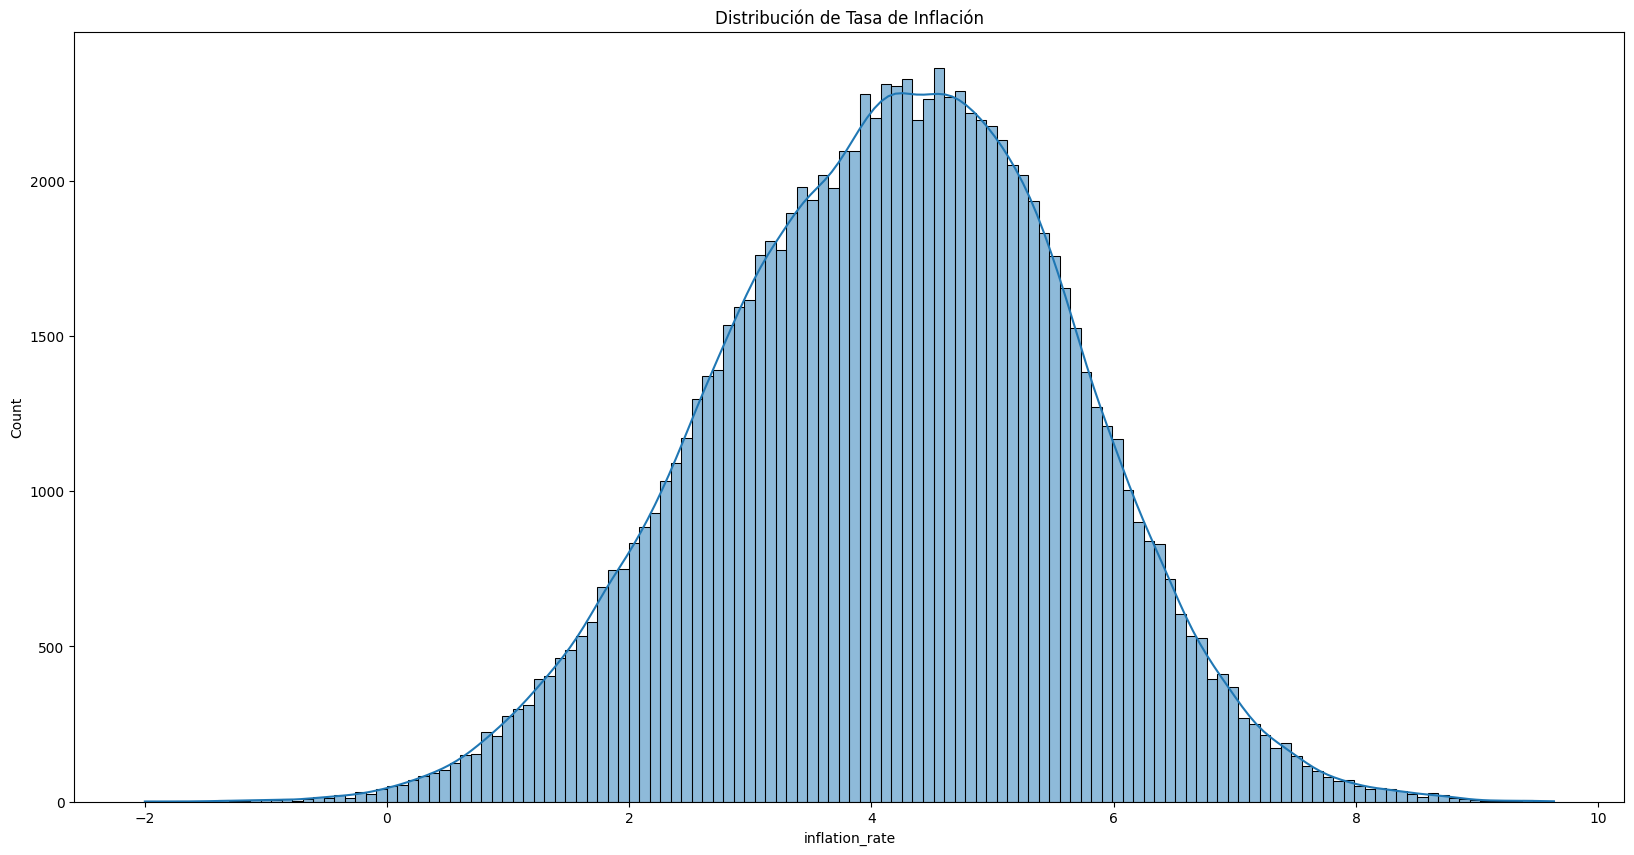

In [11]:
#Distribución de inflación
plt.figure(figsize=(20,10))
sb.histplot(df['inflation_rate'], kde=True)
plt.title("Distribución de Tasa de Inflación")
plt.show()

En el gráfico de arriba se muestra el alza y disminución de la inflación de la tasa de interés con respecto a los años 2020-2024, temporada en la que sucedieron los eventos de la pandamia de COVID-19.

En el eje X se aprecia la tasa de inflación, mientras que en el eje Y el número de filas generalizadas que fueron afectadas.

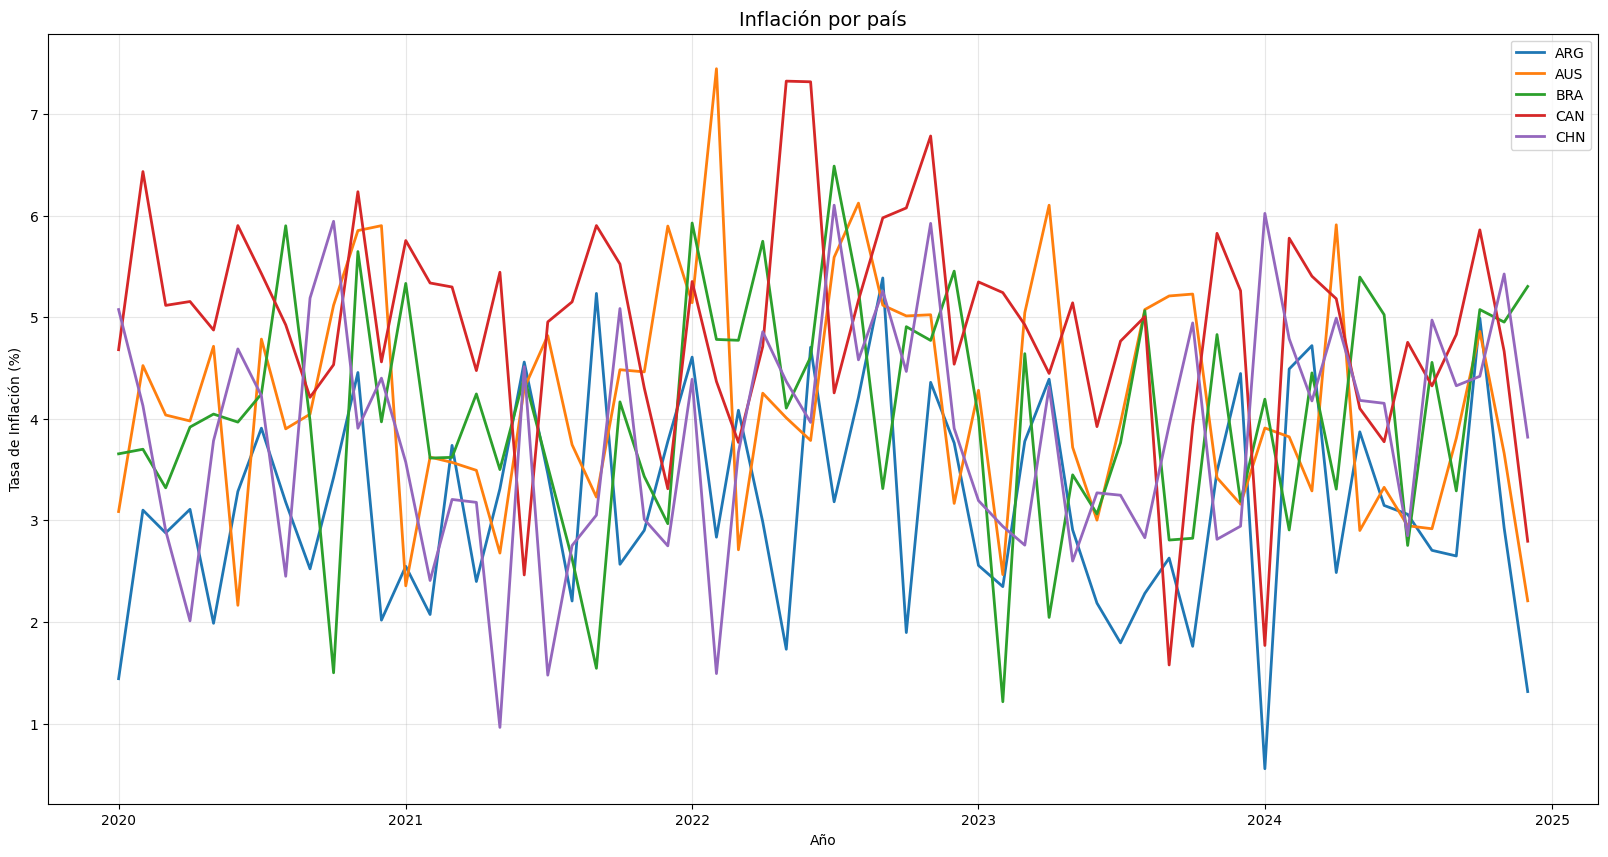

In [12]:
#Inflación por país
df_plot = df.groupby(['country', 'date'], as_index=False)['inflation_rate'].mean()
top_countries = df_plot['country'].value_counts().index[:5]

plt.figure(figsize=(20,10))

for c in top_countries:
    temp = df_plot[df_plot['country'] == c]
    plt.plot(temp['date'], temp['inflation_rate'], linewidth=2)



plt.title("Inflación por país", fontsize=14)
plt.xlabel("Año")
plt.ylabel("Tasa de Inflación (%)")
plt.legend(top_countries)
plt.grid(True, alpha=0.3)
plt.show()

En el gráfico de arriba se muestra el aumento en porcentaje de la tasa de inflación lo largo de los años que duró la pandemia.

Los países mostrados en la gráfica son los que resultaron más afectados.

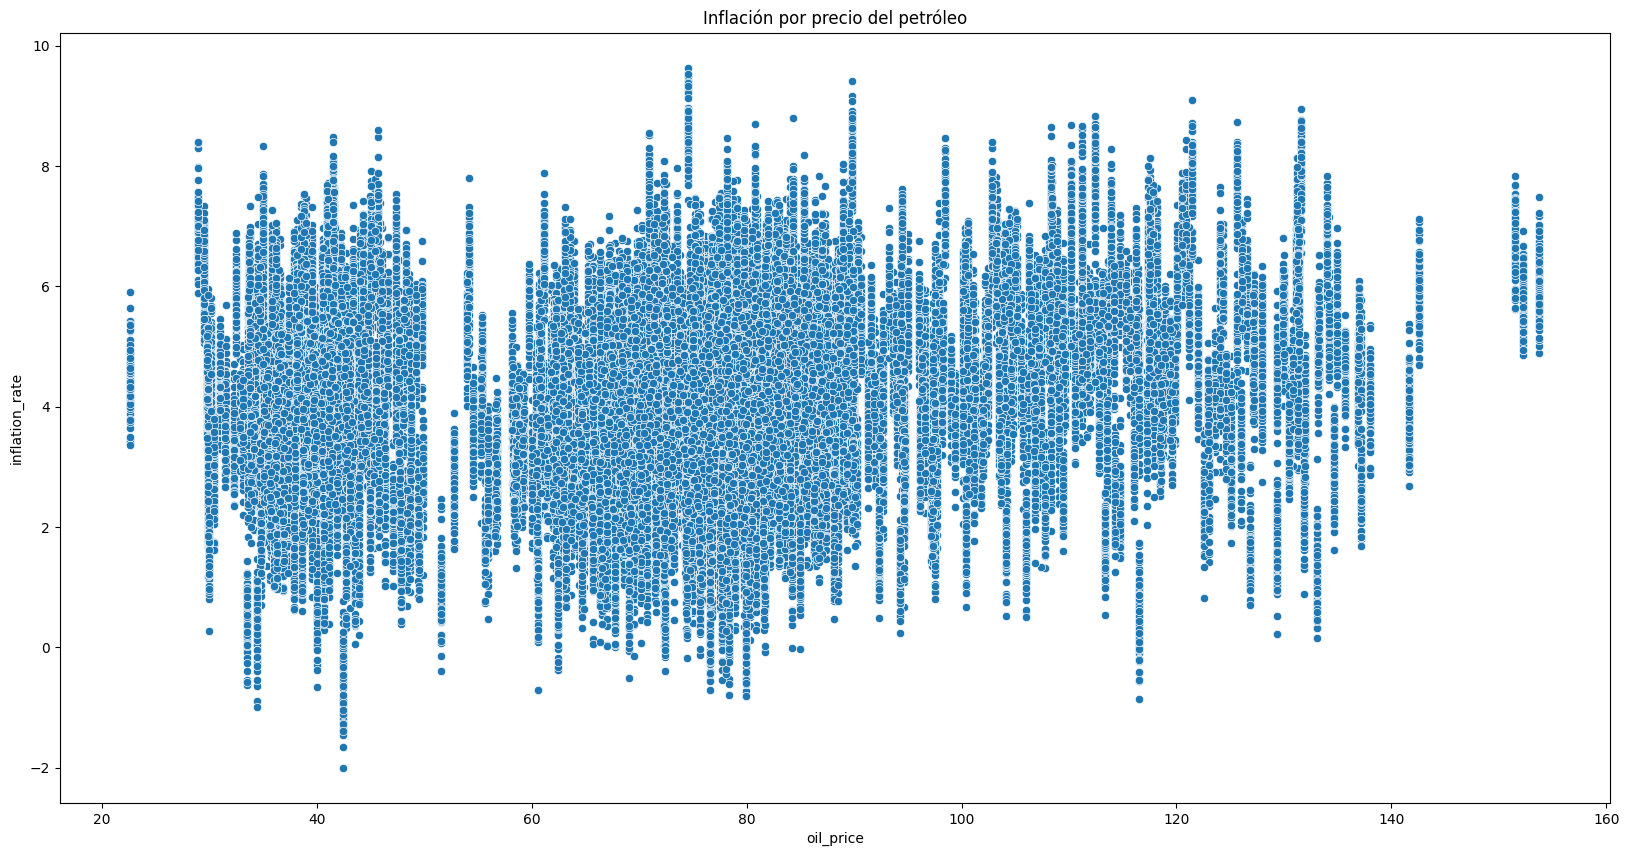

In [13]:
#inflación del petróleo
plt.figure(figsize=(20,10))
sb.scatterplot(x='oil_price', y='inflation_rate', data=df)
plt.title("Inflación por precio del petróleo")
plt.show()

La gráfica de arriba refleja el alza del precio del petróleo con respecto a la tasa de inflación.

En el eje X se aprecia el precio del petroleo, mientras que en el eje Y la tasa de inflación.

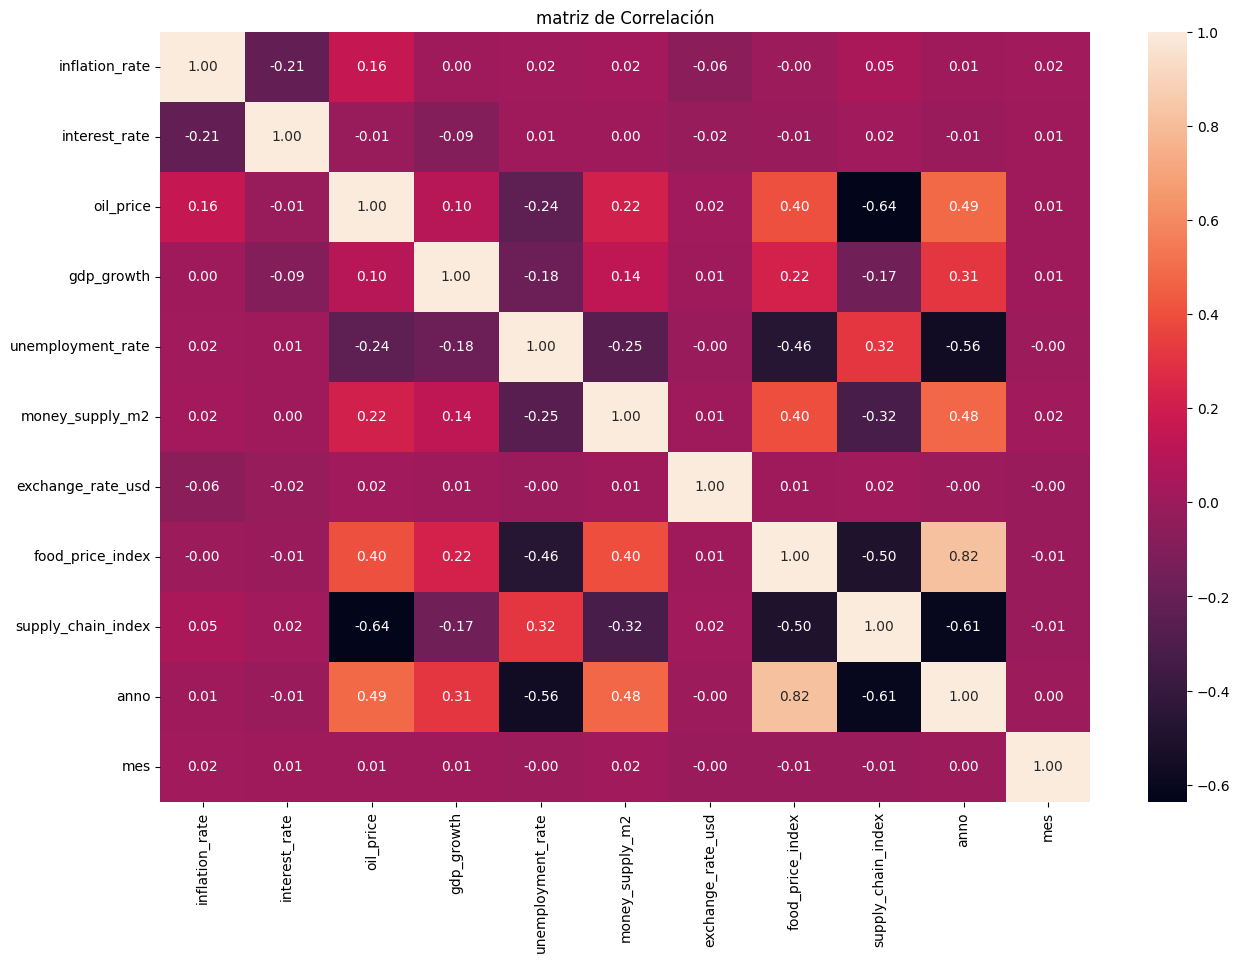

In [14]:
#Matriz de Correlación (Heatmap)
plt.figure(figsize=(15,10))
sb.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f")
plt.title("matriz de Correlación")
plt.show()

Arriba se muestra la matriz de correlación. Del lado derecho una barra que va desde valores cercanos a 0, incluso negativos, que va ascendiendo su valor. Esto indica cuánto afecta la inflación a cada área. Minetras más oscuro sea el color, peor es. Mientras que más claro sea, menor impacto recibe.

In [15]:
#Encoding
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv("/content/covid_global_procesado.csv")
df.head(100)

,country,date,inflation_rate,interest_rate,oil_price,gdp_growth,unemployment_rate,money_supply_m2,exchange_rate_usd,food_price_index,supply_chain_index,anno,mes
0,USA,2020-01-01,0.33,5.76,34.44,0.34,5.97,10558.0,69.95,94.29,3.66,2020,1
1,USA,2020-02-01,4.12,4.33,44.75,0.02,5.80,6952.0,71.03,78.60,3.91,2020,2
2,USA,2020-03-01,2.75,4.24,52.80,0.30,7.45,10244.0,71.00,102.91,3.70,2020,3
3,USA,2020-04-01,4.36,4.52,39.19,2.28,5.23,9989.0,83.52,110.92,3.23,2020,4
4,USA,2020-05-01,2.73,3.17,41.09,3.05,5.96,7982.0,70.10,86.53,3.94,2020,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,VNM,2022-12-01,4.22,2.03,136.94,3.17,6.16,11070.0,92.17,140.10,1.19,2022,12
96,VNM,2023-01-01,5.69,3.54,63.97,1.96,5.22,12914.0,98.51,129.84,1.13,2023,1
97,VNM,2023-02-01,4.94,2.43,70.75,6.69,5.58,15715.0,95.73,126.41,1.26,2023,2
98,VNM,2023-03-01,5.36,2.91,81.56,5.76,5.65,15773.0,93.67,128.33,1.75,2023,3


In [16]:
#Valores nulos
for feature in df.columns:
  print('Total valores nulos de', feature, '=', df[feature].isna().sum())

Total valores nulos de country = 0
Total valores nulos de date = 0
Total valores nulos de inflation_rate = 0
Total valores nulos de interest_rate = 0
Total valores nulos de oil_price = 0
Total valores nulos de gdp_growth = 0
Total valores nulos de unemployment_rate = 0
Total valores nulos de money_supply_m2 = 0
Total valores nulos de exchange_rate_usd = 0
Total valores nulos de food_price_index = 0
Total valores nulos de supply_chain_index = 0
Total valores nulos de anno = 0
Total valores nulos de mes = 0


In [17]:
# Selecciona solo las características que se van a considerar en los posteriores análisis
X = df.iloc[:, 3:-1].values
# La ùltima columna (sale o no sale) se separa del resto para analizar la relación que tiene ella con el resto
y = df.iloc[:, -1].values

pd.DataFrame(X).head(10)

,0,1,2,3,4,5,6,7,8
0,5.76,34.44,0.34,5.97,10558.0,69.95,94.29,3.66,2020.0
1,4.33,44.75,0.02,5.80,6952.0,71.03,78.60,3.91,2020.0
2,4.24,52.80,0.30,7.45,10244.0,71.00,102.91,3.70,2020.0
3,4.52,39.19,2.28,5.23,9989.0,83.52,110.92,3.23,2020.0
4,3.17,41.09,3.05,5.96,7982.0,70.10,86.53,3.94,2020.0
5,5.65,40.67,3.01,6.29,11775.0,67.80,93.77,3.79,2020.0
6,3.86,39.11,3.17,6.80,12359.0,73.06,89.62,3.29,2020.0
7,8.13,43.98,-0.34,6.10,10676.0,68.13,99.39,4.25,2020.0
8,3.26,44.52,-0.08,7.24,8931.0,71.77,97.88,3.51,2020.0
9,6.13,45.79,1.85,6.19,10629.0,72.39,106.73,3.63,2020.0
